In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
grng = stats.norm(loc = 5,scale = 2)
x = grng.rvs(1000)
x.sort()

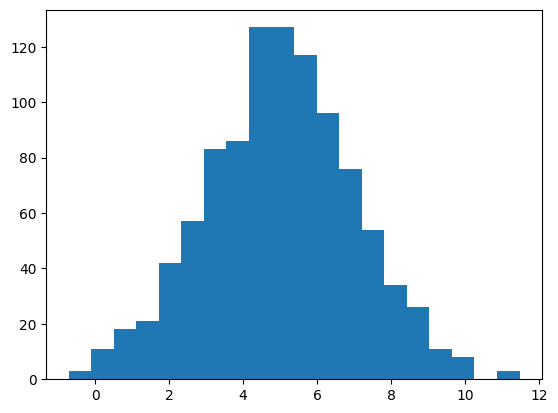

In [3]:
plt.hist(x,bins= 20);

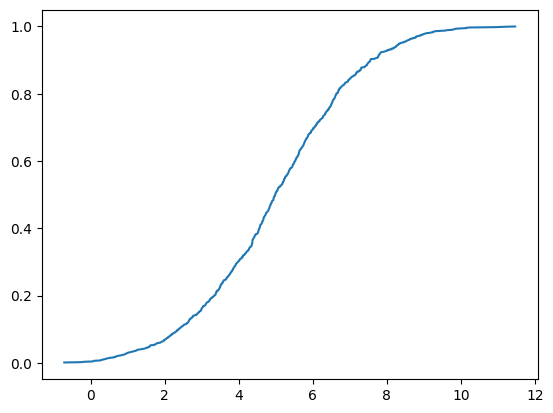

In [4]:
res = stats.ecdf(x)
plt.plot(res.cdf.quantiles,res.cdf.probabilities)

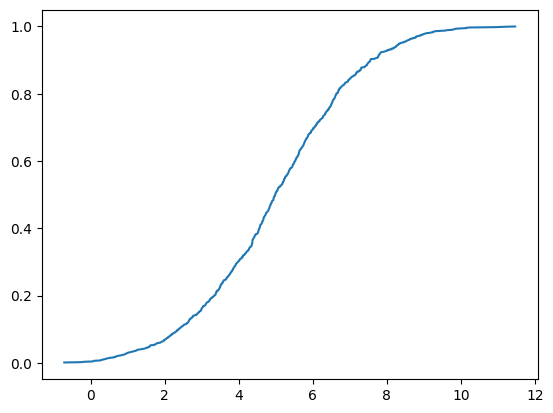

In [5]:
xs,xcounts = np.unique(x,return_counts = True)
plt.plot(xs,np.cumsum(xcounts/len(x)))

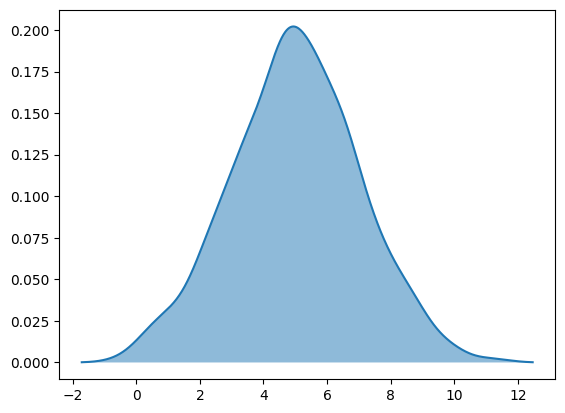

In [6]:
def plot_kde(x, ax = None):
    if not isinstance(x,np.ndarray):
        x = np.array(x)
    kde = stats.gaussian_kde(x)
    t = np.linspace(x.min()-1,x.max()+1,len(x))
    y = kde(t)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(t, y)
    ax.fill_between(t,y, alpha = .5)
    
    return ax
plot_kde(x);

In [7]:
stats.median_abs_deviation(x)

np.float64(1.377466009489554)

In [8]:
np.floor(np.random.rand(4)*4).astype(np.int16)

array([0, 2, 3, 1], dtype=int16)

In [9]:
def smoothed_bootstrap_samples(base_samples):
    x = np.sort(base_samples)
    n = len(x)

    U = np.random.rand(n) * (n - 1)
    k = np.floor(U).astype(int)
    alpha = U - k

    return (1 - alpha) * x[k] + alpha * x[k + 1]

def standard_bootstrap_samples(base_samples):
    N = len(base_samples)
    idx = np.random.randint(0, N, size=N)
    return base_samples[idx]



Text(0.5, 1.0, 'Standard bootstrap')

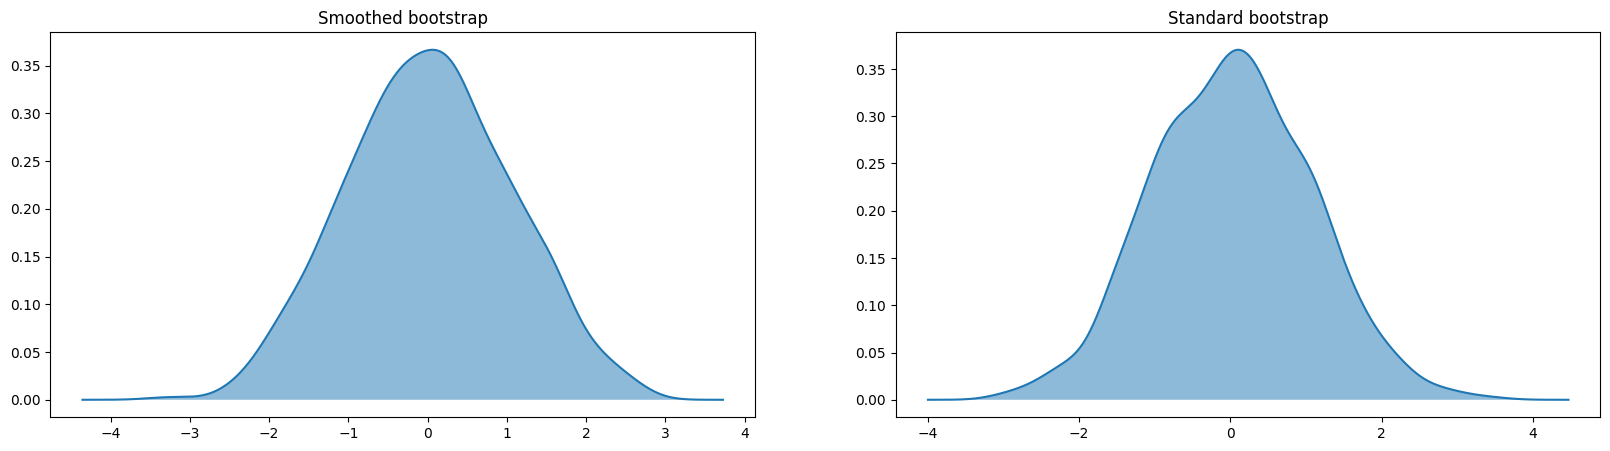

In [10]:
x_hat = x.mean()
s_hat = np.std(x, ddof = 1)
smooth_boot_samples = []
standard_boot_samples = []
fig, axes = plt.subplots(ncols =2, figsize = (20,5))
sqt_n = np.sqrt(len(x))
for _ in range(len(x)):
    smooth_boot_samples.append(sqt_n*(smoothed_bootstrap_samples(x).mean()-x_hat)/s_hat)
    standard_boot_samples.append(sqt_n*(standard_bootstrap_samples(x).mean()-x_hat)/s_hat)
ax = plot_kde(smooth_boot_samples, axes[0])
ax.set_title("Smoothed bootstrap")
ax = plot_kde(standard_boot_samples, axes[1])
ax.set_title("Standard bootstrap")


In [11]:
stats.t(21).isf(0.025)

np.float64(2.0796138447276626)

## Two state markov simulation

In [12]:
class TwoStateMarkov:
    """
    State 0 is indicated by (white), and state 1 is 1(black)
    state0_trans_prob = transition probability from state 0 (white) to state (black)
    state1_trans_prob = transition probability from state 1 (black) to state 0(white)
    """
    def __init__(self,state0_trans_prob,state1_trans_prob):
        self.state0_trans_prob = state0_trans_prob
        self.state1_trans_prob = state1_trans_prob
        self.P = np.array([[1-self.state0_trans_prob,self.state0_trans_prob],
                           [self.state1_trans_prob,1-self.state1_trans_prob]])
        
    def draw(self,state, verbose = False):
        """Given state draw from such state"""
        if state == 0:
            if verbose:
                print("Drawing from state 0")
            return 1 if np.random.rand() < self.state0_trans_prob else 0
        else: 
            if verbose:
                print("Drawing from state 1")
            return 0 if np.random.rand() < self.state1_trans_prob else 1
        
    def predict(self, init_state, n_pred=1):
        """Predict new n_pred states given init sequence"""
        assert init_state in [0,1], "Current state has to be 0, or 1"
        out = []
        v = np.zeros((2))
        v[init_state] = 1
        v = v[None,:]
        print(f"initial state is {v}")
        for _ in range(n_pred):
            v = v@self.P
            out.append(int(np.argmax(v)))
        return out
        
    @staticmethod
    def estimate_transition_prob(chain):
        cnt_z01 = 0
        cnt_o10 = 0
        total_zero = 0
        total_one = 0
        
        for i,j in zip(chain[:-1],chain[1:]):
            if i == 0:
                total_zero += 1
                if j == 1:
                    cnt_z01 += 1
            else:
                total_one += 1
                if j == 0:
                    cnt_o10 += 1

        trans_prob01 = cnt_z01/total_zero
        trans_prob10 = cnt_o10/total_one
        return trans_prob01,trans_prob10
        
    def simulate(self,n_seq,start_state=None, verbose = False):
        if start_state is None:
            self.state = np.random.randint(0,2)
        else:
            self.state = np.abs(start_state)%2
            
        self.chain = [self.state]
        for _ in range(n_seq-1):
            if verbose:
                print(f"From state: {self.state}")
            self.state = self.draw(self.state,verbose=verbose)
            if verbose:
                print(f"Drew state: {state_drawn}")
            self.chain.append(self.state)
        
        # Estimate transition probabilities
        self.trans_prob01,self.trans_prob10 = self.estimate_transition_prob(self.chain)
        
        return self
                

In [13]:
from multiprocessing import Pool

def simulate_once(args):
    p01, p10, n_draws = args
    markov = TwoStateMarkov(p01, p10)
    markov.simulate(n_draws)
    return markov.trans_prob01, markov.trans_prob10


def run_two_state_markov_simulation(p01 = .83,p10 = .56, n_run = 10,n_draws = 300):
    
    with Pool(24) as p:
        out = p.map(simulate_once,[(p01,p10,n_draws)]*n_run)
    t01,t10 = list(zip(*out))
    t01, t10 = np.mean(t01),np.mean(t10)
    print(f"Estimated transition probability from 0 to 1 = {t01}")
    print(f"Estimated transition probability from 1 to 0 = {t10}")

run_two_state_markov_simulation()

Estimated transition probability from 0 to 1 = 0.874906750530242
Estimated transition probability from 1 to 0 = 0.5435906729491361


In [14]:
M = TwoStateMarkov(.8,.625)
M.predict(0,n_pred = 5)

initial state is [[1. 0.]]


[1, 0, 1, 1, 1]

In [15]:
class ThreeStateMarkov:
    def __init__(self,init_chain,*args,**kws):
        self.chain = init_chain
        self.P = self.estimate_trans_prob(self.chain,*args, **kws)
        
    def predict(self,state, n_pred = 1):
        assert state in [0,1,2], "States can only be 0,1,2"
        v = np.zeros(3)
        v[state] = 1
        v = v[None,:]
        out = []
        for _ in range(n_pred):
            v = v@self.P
            out.append(int(np.argmax(v)))
        return out
    
    def estimate_trans_prob(self,chain, ignore_first = False):
        z01 = z10 = z12 = z21 = z02 = z20 = 0
        z0 = z1 = z2 = 0
        pairs = zip(chain[:-1],chain[1:])
        if ignore_first:
            pairs = (p for i,p in enumerate(pairs) if i != 0)
        for i,j in pairs:
            if i == 0:
                z0 += 1
                if j == 1:
                    z01 += 1
                elif j == 2:
                    z02 += 1
                else:
                    pass
            elif i == 1:
                z1 += 1
                if j == 0:
                    z10 += 1
                elif j == 2:
                    z12 += 1
                else:
                    pass
            else:
                z2 += 1
                if j == 0:
                    z20 += 1
                elif j == 1:
                    z21 += 1
                else:
                    pass
        p01 = z01/z0
        p02 = z02/z0
        p00 = 1 - p01 - p02
        p10 = z10 / z1
        p12 = z12/ z1
        p11 = 1 - p10 - p12 
        p20 = z20/z2
        p21 = z21/z2
        p22 = 1 - p21 - p20
        return np.array([[p00, p01, p02],
                    [p10,p11, p12],
                    [p20, p21 ,p22]])
        

In [16]:
# sunny = 0, rain = 1, cloudy = 2
three_states = ThreeStateMarkov([0,1,2,2,1,1,0,0,2,0,1,2,0,1], ignore_first = True)
three_states.predict(1,3)

[2, 0, 1]

## Confidence intervals around proportions

In [17]:
def wilson_proportion(x,n,alpha = 0.05):
    """Estimates confidence interval for proportions of a binomial distribution"""
    z = stats.norm.isf(alpha/2)
    a = (1+(z**2)/n)
    b = -(2*x + z**2)/n
    c = (x/n)**2
    l = (-b - np.sqrt(b**2 - 4*a*c))/(2*a)
    u = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)
    return (l,u)

def agresti_coull_proportion(x,n,alpha=0.05):
    z = stats.norm.isf(alpha/2)
    x_bar = x + z*z/2
    n_bar = n + z*z
    p = x_bar/n_bar
    sigma = np.sqrt(p*(1-p)/n_bar)
    l = p - z*sigma
    u = p + z*sigma
    return l, u

In [18]:
wilson_proportion(78,n= 125)

(np.float64(0.5365826693275706), np.float64(0.7040231130327644))

In [19]:
agresti_coull_proportion(78,n= 125)

(np.float64(0.5365035079749372), np.float64(0.704102274385398))

## Poisson model

In [20]:
from scipy import integrate
from scipy import special

In [21]:
from enum import Enum
class BayesianPrior(Enum):
    UNIFORM = 1
    JEFFREY = 2
    CONJUGATE = 3
    GAUSSIAN = 4
    BETA = 5
    CUSTOM = 6
    
@np.vectorize
def custom_fun(x):
    if x >= 0 and x <=2:
        return x
    elif x > 2 and x <=  4:
        return 2
    elif x > 4 and x <= 8: 
        return -0.5*x + 8
    else: return 0
    
class PoissonModel:
    def __init__(self, data, prior_type = BayesianPrior.UNIFORM, m = None, s = None, prior_fun = None,prior_support = None):
        # process data
        self.data = data        
        if not isinstance(self.data, np.ndarray):
            self.data = np.array(self.data)
        assert self.data.ndim == 1, "data must be 1-D array"
        self._n = len(data)
        # save arguments, and compute posterior distribution
        self.prior_type = prior_type        
        self._init_posterior(m, s, prior_fun, prior_support)
        
    def _init_posterior(self,m = None, s = None, prior_fun = None, prior_support = None):

        if self.prior_type  == BayesianPrior.UNIFORM:
            self._r = data.sum() + 1
            self._v = self._n
            
        elif self.prior_type == BayesianPrior.JEFFREY:
            self._r =  data.sum() + .5
            self._v = self._n

        elif self.prior_type == BayesianPrior.CONJUGATE:
            assert m is not None and s is not None, "For CONJUGATE priors, you must specify your prior mean, and standard deviation"
            self._r = data.sum() + (m**2)/(s**2)
            self._v = m/s**2 + self._n
            
        elif self.prior_type == BayesianPrior.CUSTOM:     
            assert prior_fun is not None and prior_support is not None,"For CUSTOM priors, you must specify prior_fun function, and a support of the function, a probabiliy function."
            self._r =  None
            self._v = None
            self.prior_fun = prior_fun
            self.prior_support = prior_support
            l,u = self.prior_support
            norm_const,_ = integrate.quad(lambda x: self.prior_fun(x)*self.poisson_likelihood(x),l,u)
            self.custom_mean,_ = integrate.quad(lambda x: x*self.prior_fun(x)*self.poisson_likelihood(x)/norm_const,l,u)
            self.custom_var,_ = integrate.quad(lambda x: (x-self.custom_mean)**2*self.prior_fun(x)*self.poisson_likelihood(x)/norm_const,l,u)
            
        else:
            raise ValueError("prior_type can only be UNIFORM,JEFFREY, CONJUGATE, OR CUSTOM from the enum class BayesianPrior")
        if self._r is not None and self._v is not None:
            self._create_posterior(self._r, self._v)
        
    def _create_posterior(self,r,v): 
        self.post = stats.gamma(a = r, scale = 1/v)
        
    @property
    def poisson_likelihood(self):
        s = self.data.sum()
        return lambda x: np.array(x)**s*np.exp(-self._n*np.array(x))
    
    def update_prior(self, prior_type,m = None, s = None, prior_fun = None,prior_support=None):
        self.prior_type = prior_type
        self._init_posterior(m,s,prior_fun, prior_support)
        
    @property
    def posterior_mean(self):
        if self._r is not None:
            return self._r/ self._v
        else:
            return self.custom_mean
    
    @property
    def posterior_variance(self):
        if self._r is not None:
            return self._r/(self._v**2)
        else: return self.custom_var
    
    @property
    def posterior_std(self):
        return np.sqrt(self.posterior_variance)
    
    def credible_interval(self, alpha = 0.05):
        half = alpha/2
        if self._r is not None:
            return self.post.ppf(half), self.post.isf(half)
        else:
            raise ValueError("Not implemented. May implement using  bisection method?")
            

    

In [22]:
data = np.array([3,2,0,8,2,4,6,1])
priors = (BayesianPrior.UNIFORM,BayesianPrior.JEFFREY,BayesianPrior.CONJUGATE,BayesianPrior.CUSTOM)
pois_model = PoissonModel(data, prior_type = BayesianPrior.UNIFORM,prior_fun = custom_fun, prior_support = (0,10), m = 2.5,s=1)
for p in priors:
    pois_model.update_prior(prior_type = p,prior_fun = custom_fun, prior_support = (0,10), m = 2.5,s=1)
    print("-"*50 + f" {p.name} "+ "-"*50)
    print(f"Posterior mean = {pois_model.posterior_mean}")
    print(f"Posterior std = {pois_model.posterior_std}")
    if p != BayesianPrior.CUSTOM:
        print(f"credible interval = {pois_model.credible_interval()}")

-------------------------------------------------- UNIFORM --------------------------------------------------
Posterior mean = 3.375
Posterior std = 0.649519052838329
credible interval = (np.float64(2.224146266470597), np.float64(4.762003010390624))
-------------------------------------------------- JEFFREY --------------------------------------------------
Posterior mean = 3.3125
Posterior std = 0.6434768838116876
credible interval = (np.float64(2.173520538543164), np.float64(4.68761652012054))
-------------------------------------------------- CONJUGATE --------------------------------------------------
Posterior mean = 3.0714285714285716
Posterior std = 0.5408484138857403
credible interval = (np.float64(2.1042525854858147), np.float64(4.218607942977403))
-------------------------------------------------- CUSTOM --------------------------------------------------
Posterior mean = 3.6185779460130933
Posterior std = 0.7322787124218405


## Bayesian Inference for Normal mean

In [23]:
class GaussianModel:
    def __init__(self,data,variance = None , prior_type = BayesianPrior.UNIFORM , prior_mean = None,prior_var = None,prior_values = None,prior_prob = None):
        self.data = data
        self.variance = np.var(self.data, ddof = 1) if variance is None else variance
        if prior_prob is None and prior_values is None:
            assert prior_type in [BayesianPrior.UNIFORM, BayesianPrior.GAUSSIAN], "For continuous, prior, use UNIFORM or GAUSSIAN priors"
        
            
        self._init_posterior(prior_type,prior_mean, prior_var, prior_values, prior_prob)
    
    def _init_posterior(self,prior_type,prior_mean = None, prior_var = None, prior_values = None, prior_prob = None):
        
        self.prior_prob = prior_prob
        self.prior_values = prior_values
        self._n = len(self.data)
        self.data_mean = self.data.mean()
        if self.prior_prob is not None and self.prior_values is not None: ## Discrete prior case
            assert len(self.prior_values) == len(self.prior_prob), "prior_values, and prior_prob should have the same length"
            if not isinstance(self.prior_prob,np.ndarray):
                raise TypeError("prior_prob must be an numpy array of discrete probabilities for the prior Gaussian mean")
            if not isinstance(self.prior_values,np.ndarray):
                raise TypeError("prior_values must be an array of prior values for the Gaussian mean of the likelihood function.")
            
            self.post_dist = self._discrete_posterior()
            self.post_mean = self.post_dist.mean()
            self.post_var = self.post_dist.var(ddof = 1)
            
        else: # Continuous prior case
            assert not isinstance(prior_mean,np.ndarray), "prior mean should just be a float number"
            self.prior_type = prior_type
            self.prior_var = prior_var
            self.prior_mean = prior_mean

            if self.prior_type == BayesianPrior.UNIFORM:
                self.post_mean = self.data_mean
                self.post_var = self.variance/self._n
                self.post_dist = stats.t(df = self._n - 1,loc = self.post_mean , scale = np.sqrt(self.post_var)) if self.variance is None else stats.norm(loc = self.post_mean , scale = np.sqrt(self.post_var))
            elif self.prior_type == BayesianPrior.GAUSSIAN:
                assert self.prior_mean is not None and self.prior_var is not None, "Both prior_mean, and prior_var of Gaussian prior must be specified"
                svar = self.variance/self._n
                v = self.prior_var + svar
                self.post_var = svar*self.prior_var/v
                self.post_mean = (svar*self.prior_mean + self.prior_var*self.data_mean)/v
                self.post_dist = stats.t(df = self._n - 1,loc = self.post_mean , scale = np.sqrt(self.post_var)) if self.variance is None else stats.norm(loc = self.post_mean , scale = np.sqrt(self.post_var))
            else:
                raise ValueError("prior_type must be one of these: BayesianPrior.UNIFORM, Bayesian.GAUSSIAN")
    
    def _discrete_posterior(self):
        x = -0.5*(1/self.variance)
        lh = np.exp(self._n*x*(self.data_mean - self.prior_values)**2)
        prior_times_lh = self.prior_prob*lh
        postrior = prior_times_lh/pr_lh.sum()
        return postrior
    
    def update_prior(self, prior_type,prior_mean = None, prior_var = None, prior_values = None,prior_prob = None):
        self._init_posterior(prior_type,prior_mean, prior_var,prior_values, prior_prob)
        
    @property
    def posterior_mean(self):
        return self.post_mean
    
    @property
    def posterior_variance(self):
        return self.post_var
    
    @property
    def posterior_std(self):
        return np.sqrt(self.posterior_variance)
    
    def credible_interval(self, alpha = 0.05):
        half = alpha/2
        if self.prior_prob is None:
            return self.post_dist.ppf(half), self.post_dist.isf(half)
        else:
            return np.quantile(self.post_dist, [half, 1-half])
    
class GaussianModelTwoIndSamples:
    def __init__(self,
                 sample1,
                 sample2,
                 var1 = None,
                 var2 = None,
                 is_var_known = False,
                 is_equal_var = True,
                 prior_type = BayesianPrior.UNIFORM,
                 prior_mean1 = 0,
                 prior_mean2 = 0,
                 prior_var1 = 1,
                 prior_var2 = 1):
        assert  is_var_known, "If your variances var1, and var2 known, please set is_var_known to True"
        assert prior_type in [BayesianPrior.UNIFORM, BayesianPrior.GAUSSIAN], "For continuous, prior, use UNIFORM or GAUSSIAN priors"
        if var1 is None and var2 is None:
            if is_var_known:
                raise ValueError("If your variances var1, and var2 unknown, please set is_var_known to False")
            
        if var1 is not None and var2 is not None:
            if not is_var_known:
                raise ValueError("If your variances var1, and var2 unknown, please set is_var_known to True")
            
        
        self.sample1 = sample1
        self.sample2 = sample2
       
        self._init_posterior(var1,
                             var2,
                             is_var_known,
                             is_equal_var,
                             prior_type,
                             prior_mean1,
                             prior_mean2,
                             prior_var1,
                             prior_var2)
        
    def _init_posterior(self,
            var1 = None,
            var2 = None,
            is_var_known = False,
            is_equal_var = True,
            prior_type = BayesianPrior.UNIFORM,
            prior_mean1 = 0,
            prior_mean2 = 0,
            prior_var1 = 1,
            prior_var2 = 1):
        self.var1 = var1
        self.var2 = var2
        self.is_equal_var = is_equal_var
        self.is_var_known = is_var_known
        self.prior_type = prior_type
        self.prior_mean1 = prior_mean1
        self.prior_mean2 = prior_mean2
        self.prior_var1 = prior_var1
        self.prior_var2 = prior_var2
        
        ## Known variance
        if is_var_known:
            # Both Equal and unequal variance 
            self.model1 = GaussianModel(self.sample1,
                                    variance = self.var1,
                                    prior_type = self.prior_type,
                                    prior_mean = self.prior_mean1,
                                    prior_var = self.prior_var1,
                                    prior_values = None,
                                    prior_prob = None)
            self.model2 = GaussianModel(self.sample2,
                variance = self.var1,
                prior_type = self.prior_type,
                prior_mean = self.prior_mean2,
                prior_var = self.prior_var2,
                prior_values = None,
                prior_prob = None)
            self.post_mean = self.model1.posterior_mean - self.model2.posterior_mean
            self.post_var = self.model1.posterior_variance + self.model2.posterior_variance
            self.post_dist = stats.norm(loc = self.post_mean, scale = np.sqrt(self.post_var))
                
        else:# Unknown variance
            m1 = np.mean(self.sample1)
            m2 = np.mean(self.sample2)
            n1 = len(self.sample1)
            n2 = len(self.sample2)
            if is_equal_var:# Equal variance
                ddof =  n1 + n2 - 2
                pool_var =  (((self.sample1 - m1)**2).sum() + ((self.sample2 - m2)**2).sum())/ddof
                if self.prior_type  == BayesianPrior.UNIFORM:
                    self.post_var = pool_var*(1/n1 + 1/n2)
                    self.post_mean = m1 - m2
                    self.post_dist = stats.t(df = ddof, loc = self.post_mean, scale = np.sqrt(self.post_var))
                else: # GAUSSIAN PRIOR
                    sample1_post_mean = (pool_var*self.prior_mean1 + n1*self.prior_var1*m1)/(pool_var + n1*self.prior_var1) # sample1 posterior mean
                    sample2_post_mean = (pool_var*self.prior_mean2 + n2*self.prior_var2*m2)/(pool_var + n2*self.prior_var2) # sample2 posterior mean
                    sample1_post_var = pool_var*self.prior_var1/(pool_var + n1*self.prior_var1) ## sample1 posterior variance
                    sample2_post_var = pool_var*self.prior_var2/(pool_var + n2*self.prior_var2) # # sample2 posterior variance
                    self.post_mean = sample1_post_mean - sample2_post_mean
                    self.post_var = sample1_post_var + sample2_post_var
                    self.post_dist = stats.t(df = ddof, loc = self.post_mean, scale = np.sqrt(self.post_var))
                    
            else:# Unequal variance
                sample1_var = np.var(self.sample1, ddof = 1)
                sample2_var = np.var(self.sample2, ddof = 1)
                s1 = sample1_var/n1
                s2 = sample2_var/n2
                num = (s1 + s2)**2
                den = (s1**2)/(n1 - 1) + (s2**2)/(n2 - 1)
                ddof = int(num/den) # Statterthwaite suggestion
                if self.prior_type  == BayesianPrior.UNIFORM:
                    self.post_mean = m1 - m2
                    self.post_var = s1 + s2
                    self.post_dist = stats.t(df = ddof, loc = self.post_mean, scale = np.sqrt(self.post_var))
                else: # GUASSIAN PRIOR
                    sample1_post_mean = (sample1_var*self.prior_mean1 + n1*self.prior_var1*m1)/(sample1_var + n1*self.prior_var1) # sample1 posterior mean
                    sample2_post_mean = (sample2_var*self.prior_mean2 + n2*self.prior_var2*m2)/(sample2_var + n2*self.prior_var2)  # sample2 posterior mean
                    sample1_post_var = sample1_var*self.prior_var1/(sample1_var + n1*self.prior_var1) ## sample1 posterior variance
                    sample2_post_var = sample2_var*self.prior_var2/(sample2_var + n2*self.prior_var2) # # sample2 posterior variance
                    self.post_mean = sample1_post_mean - sample2_post_mean
                    self.post_var = sample1_post_var + sample2_post_var
                    self.post_dist = stats.t(df = ddof, loc = self.post_mean, scale = np.sqrt(self.post_var))
                
    def update_prior(var1 = None,
            var2 = None,
            is_var_known = False,
            is_equal_var = True,
            prior_type = BayesianPrior.UNIFORM,
            prior_mean1 = 0,
            prior_mean2 = 0,
            prior_var1 = 1,
            prior_var2 = 1):
        self._init_posterior(var1,
                             var2,
                             is_var_known,
                             is_equal_var,
                             prior_type,
                             prior_mean1,
                             prior_mean2,
                             prior_var1,
                             prior_var2)
        
    @property
    def posterior_mean(self):
        return self.post_mean
    
    @property
    def posterior_variance(self):
        return self.post_var
    
    @property
    def posterior_std(self):
        return np.sqrt(self.posterior_variance)
    
    def credible_interval(self, alpha = 0.05):
        half = alpha/2
        return self.post_dist.ppf(half), self.post_dist.isf(half)

In [25]:
sample_data = np.array([3.2,2.2,3.6,4.1])
variance = 1
prior_values = np.array([2,2.5,3,3.5,4])
prior_prob = np.ones_like(prior_values)/len(prior_values)
gaussian_model = GaussianModel(sample_data,variance = variance, prior_mean = None,prior_var=None, prior_prob = None, prior_values = None)

In [26]:
sample_data = np.array([79.9,80,78.9,78.5,75.6,80.5,82.5,80.1,81.6,76.7])
variance = 4
gaussian_model = GaussianModel(sample_data,variance = variance,prior_type = BayesianPrior.GAUSSIAN, prior_mean = 75,prior_var=100, prior_prob = None, prior_values = None)
print(f"credible interval = {gaussian_model.credible_interval()}")

credible interval = (np.float64(78.17523230029461), np.float64(80.64946889492451))


In [27]:
sample1 = np.array([115,120,111,123,116,121,118,116,127,129])
sample2 = np.array([123,131,113,119,123,113,128,126,125,128])
variance = 36
prior_mean = 100
prior_var = 20**2
two_sample_model = GaussianModelTwoIndSamples(sample1,
                                              sample2,
                                              is_var_known = True,
                                              prior_type = BayesianPrior.GAUSSIAN,
                                              var1 = variance,
                                              var2 = variance,
                                              prior_mean1 = prior_mean,
                                              prior_mean2 = prior_mean,
                                              prior_var1 = prior_var,
                                              prior_var2 = prior_var)
two_sample_model.credible_interval()

(np.float64(-8.506192608117594), np.float64(1.965062776601223))

## Importance sampling
Is there automatic way to determine **importance distribution**?

In [28]:
from scipy import special
def weight(x):
    mask = np.logical_and(x>0, x<1)
    x = x[mask]
    num = x*(1-x)**7 # Target proportional distribution
    den = np.exp(-((x - .2)**2)/(2*.015)) # proportional importance distribution
    w = num/den
    w = w/w.sum()
    return w,x

def sample(N = 10000):
    rng = np.random.default_rng()
    x = stats.norm(loc = 0.2,scale = np.sqrt(0.015)).rvs(100000, random_state = rng)
    w, x = weight(x)
    
    idx = rng.choice(len(x),size =  N, replace = True, p = w)
    return x[idx]
    

<Axes: >

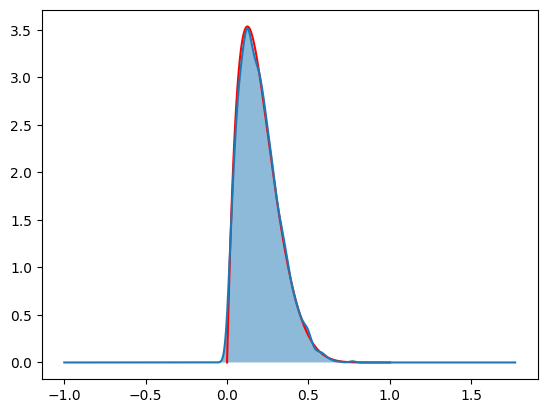

In [29]:
y = sample()
fig,ax = plt.subplots()
# ax.hist(y,bins = 100,density = True);
x = np.linspace(0,1,10000)
z = special.gamma(10)/(special.gamma(8)*special.gamma(2))*x*(1-x)**7
ax.plot(x,z, color = "r")
plot_kde(y,ax = ax)

## Markov Chain Monte Carlo(MCMC)
### Metropolis-Hastings Algorithm for a single Parameter

In [79]:
class Metropolis_Hastings:
    """For now I assume that the candidate is a gaussian distribution. I will relax this for a generic density later"""
    def __init__(self, target_fn, num_samples = 10000, warm_up = 200,lag = 10, candidate_variance = 1, candidate_mean = 2):
        self.target_fn  = target_fn
        self.warm_up = warm_up
        self.lag = lag
        self.num_samples = num_samples
        self.candidate_variance = candidate_variance
        self.current = candidate_mean
        self.candidate_fn = stats.norm(loc = self.current, scale = np.sqrt(self.candidate_variance))
        self.sample_ = []
        self.uniform_dist = stats.uniform()
        self._variate_accepted = False
        
    def run_mcmc(self):
        candidate = self.candidate_fn.rvs(1)[0]
        alpha = np.min([1,self.target_fn(candidate)/self.target_fn(self.current)])
        u = self.uniform_dist.rvs(1)
        if u < alpha: # accept condition
            self._variate_accepted = True
            self.current = candidate
            self.candidate_fn = stats.norm(loc = self.current, scale = np.sqrt(self.candidate_variance))
        else:
            self._variate_accepted = False
            
    def fit(self):
        for _ in range(self.warm_up):
            self.run_mcmc()
            
        i = 0
        while len(self.sample_) < self.num_samples:
            self.run_mcmc()
            i += 1
            if i == self.lag:
                i = 0
                if self._variate_accepted:
                    self.sample_.append(self.current)

        self.sample_ = np.array(self.sample_)
        
    def plot_trace(self, bins = 100, kde = False, figsize = (10,5)):
        assert len(self.sample_) != 0, "Please call the fit method first."
        fig, (ax1, ax2) = plt.subplots(ncols = 2,figsize = figsize)
        ax1.plot(np.arange(len(self.sample_)),self.sample_)
        ax1.set_title("Trace plot")
        if kde:
            plot_kde(self.sample_, ax = ax2)
            ax2.set_title("Sample KDE")
        else:
            ax2.hist(self.sample_, bins  = bins)
            ax2.set_title("Sample Histogram")
        return (ax1, ax2)

            
                
        
        

In [39]:
def target_fn(x):
    a = np.exp(-x*x/2)
    b = 2*np.exp(-0.5*((x-3)/0.5)**2)
    c = 2*np.exp(-0.5*((x+3)/0.5)**2)
    return 0.7*a + 0.15*b + 0.15*c



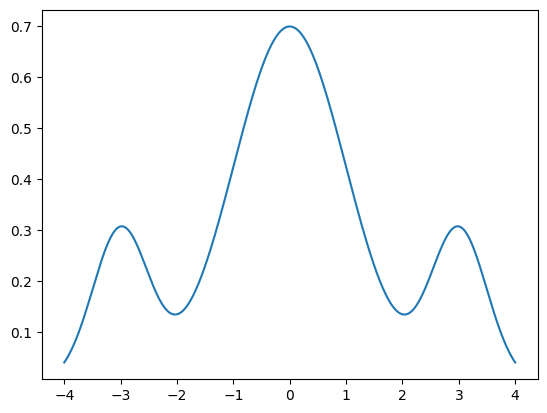

In [53]:
t  = np.linspace(-4,4,1000)
plt.plot(t,target_fn(t))

In [83]:
mh_mcmc = Metropolis_Hastings(target_fn, lag = 10)
mh_mcmc.fit()

In [84]:
len(mh_mcmc.sample_)

10000

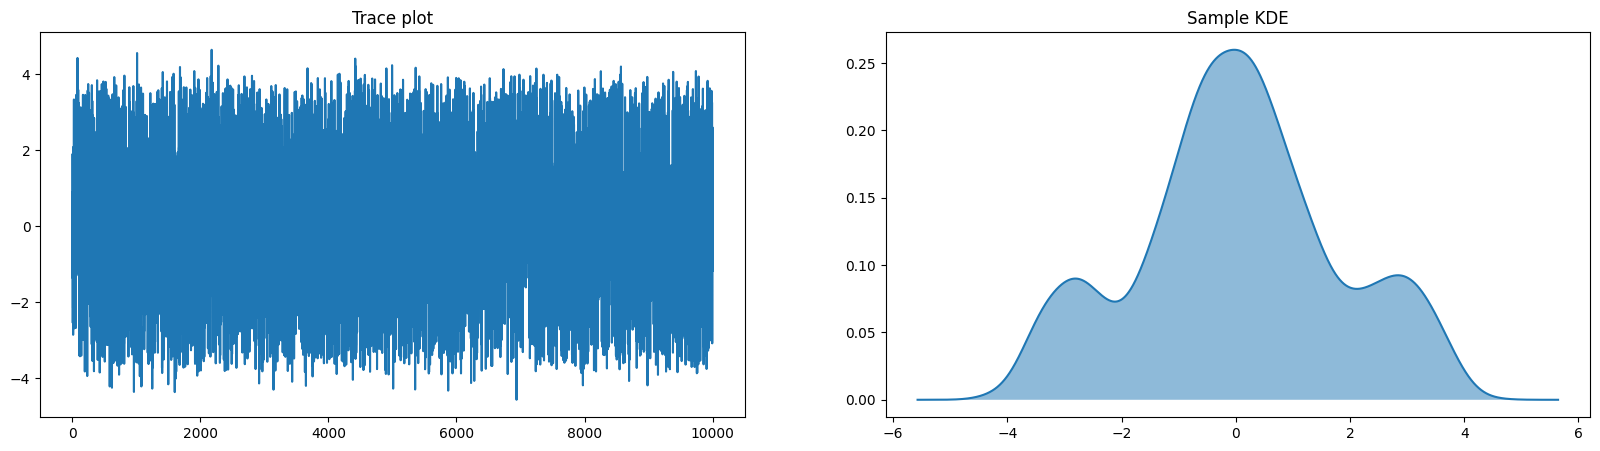

In [85]:
mh_mcmc.plot_trace(kde = True,figsize=(20,5));